All libraries imported successfully!
CREDIT CARD FRAUD DETECTION - ANOMALY DETECTION WITH IMBALANCED HANDLING
\n1. Loading dataset...
Dataset shape: (284807, 31)
Missing values:\n0
\nClass distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


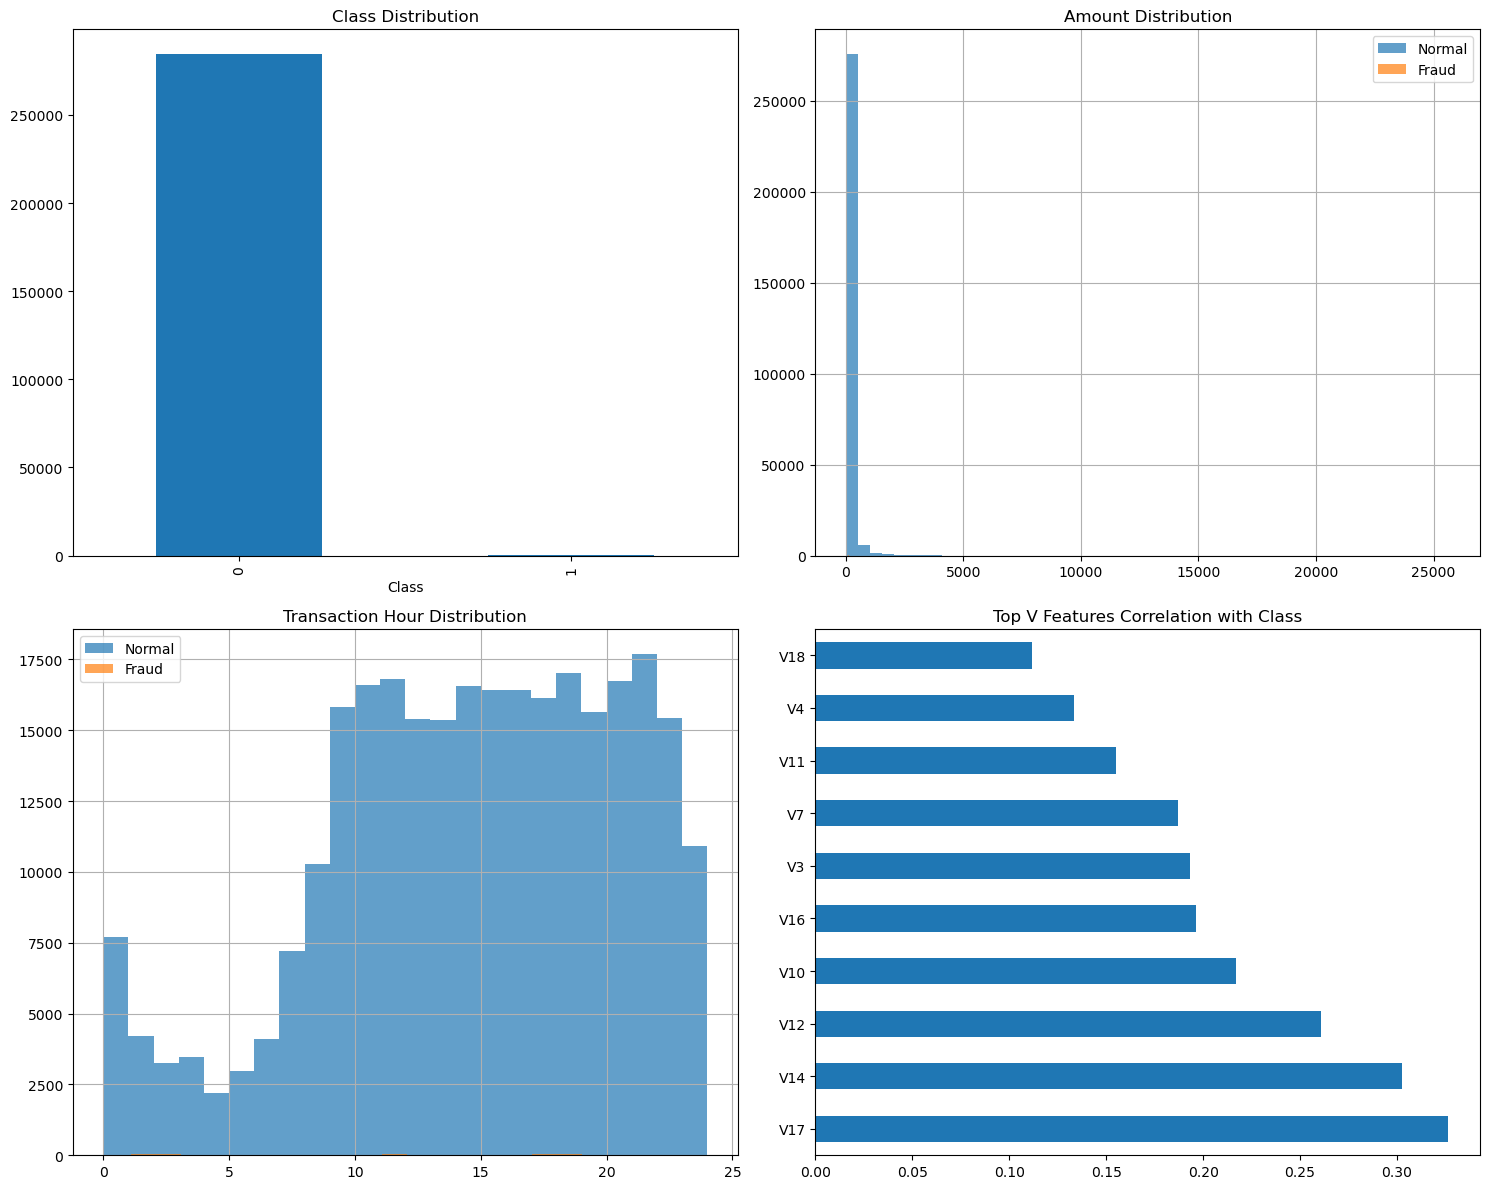

EDA complete. Dataset: 284807 transactions, 0.172% fraud (highly imbalanced)
\n2. Preprocessing...
Train: (170883, 30), Val: (56962, 30), Test: (56962, 30)
Preprocessing complete.
\n3. Anomaly Detection Models (Unsupervised/Semi-supervised)...
Training anomaly detectors...
IsolationForest: Val ROC-AUC = 0.6204


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, matthews_corrcoef,
    make_scorer
)
from sklearn.pipeline import Pipeline

# Imbalanced Learning
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss, 
    TomekLinks, EditedNearestNeighbours
)
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    IsolationForest
)
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import DBSCAN
import joblib

print("All libraries imported successfully!")

print("CREDIT CARD FRAUD DETECTION - ANOMALY DETECTION WITH IMBALANCED HANDLING")

# Step 1: Data Loading & Initial EDA
print("\\n1. Loading dataset...")
df = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"Missing values:\\n{df.isnull().sum().sum()}")
print("\\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Class imbalance
df['Class'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Class Distribution')

# Amount distribution
df[df['Class']==0]['Amount'].hist(bins=50, alpha=0.7, label='Normal', ax=axes[0,1])
df[df['Class']==1]['Amount'].hist(bins=50, alpha=0.7, label='Fraud', ax=axes[0,1])
axes[0,1].set_title('Amount Distribution')
axes[0,1].legend()

# Time distribution
df['Time_Hour'] = (df['Time'] % (24*3600)) / 3600
df[df['Class']==0]['Time_Hour'].hist(bins=24, alpha=0.7, label='Normal', ax=axes[1,0])
df[df['Class']==1]['Time_Hour'].hist(bins=24, alpha=0.7, label='Fraud', ax=axes[1,0])
axes[1,0].set_title('Transaction Hour Distribution')
axes[1,0].legend()

# V1-V28 correlation with Class (top 10)
corr = df.drop(['Time', 'Amount'], axis=1).corr()['Class'].abs().sort_values(ascending=False)[1:11]
corr.plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('Top V Features Correlation with Class')

plt.tight_layout()
plt.savefig('eda_plots.png')
plt.show()

print("EDA complete. Dataset: 284807 transactions, 0.172% fraud (highly imbalanced)")

# Step 2: Feature Engineering & Preprocessing
print("\\n2. Preprocessing...")
X = df.drop('Class', axis=1)
y = df['Class']

# Time engineering
X['Time_Hour'] = (X['Time'] % (24*3600)) / 3600
X = X.drop('Time', axis=1)

# Split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete.")

# Step 3: Define Models & Imbalanced Strategies
print("\\n3. Anomaly Detection Models (Unsupervised/Semi-supervised)...")

# Pure Anomaly Detection (train on normal only)
models = {
    'IsolationForest': IsolationForest(contamination=0.0017, random_state=42),
    'LocalOutlierFactor': LocalOutlierFactor(n_neighbors=20, contamination=0.0017),
    'OneClassSVM': OneClassSVM(nu=0.0017),
    'EllipticEnvelope': EllipticEnvelope(contamination=0.0017, random_state=42),
}

# Train anomaly models on normal data only
print("Training anomaly detectors...")
anomaly_results = {}
for name, model in models.items():
    if hasattr(model, 'fit_predict'):  # LOF doesn't have fit
        model.fit(X_train_scaled[y_train == 0])
        preds_train = model.predict(X_train_scaled) == -1
        preds_val = model.predict(X_val_scaled) == -1
        auc_val = roc_auc_score(y_val, preds_val)
        anomaly_results[name] = auc_val
        print(f"{name}: Val ROC-AUC = {auc_val:.4f}")

print("\\nTop Anomaly Model:", max(anomaly_results, key=anomaly_results.get))

# Step 4: Imbalanced Pipelines + Supervised Baselines
print("\\n4. Imbalanced Pipelines + Supervised Baselines...")

resamplers = {
    'SMOTE': SMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'NoResample': None
}

supervised_models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), random_state=42),
}

results = []
for res_name, resampler in resamplers.items():
    for model_name, model in supervised_models.items():
        pipe = ImbPipeline([('sampler', resampler)] + [('classifier', model)]) if resampler else Pipeline([('classifier', model)])
        pipe.fit(X_train_scaled, y_train)
        preds_val = pipe.predict(X_val_scaled)
        auc = roc_auc_score(y_val, preds_val)
        pr_auc = average_precision_score(y_val, preds_val)
        f1 = f1_score(y_val, preds_val)
        results.append({
            'Resampler': res_name,
            'Model': model_name,
            'ROC-AUC': auc,
            'PR-AUC': pr_auc,
            'F1': f1
        })

results_df = pd.DataFrame(results)
print("\\nModel Comparison:")
print(results_df.sort_values('ROC-AUC', ascending=False).round(4))

# Step 5: Test Best Models
print("\\n5. Final Test Evaluation...")
best_supervised = results_df.loc[0, 'Resampler'], results_df.loc[0, 'Model']
best_anomaly = max(anomaly_results, key=anomaly_results.get)

print(f"Best Supervised: {best_supervised[0]} + {best_supervised[1]}")
print(f"Best Anomaly: {best_anomaly}")

# Save best model
joblib.dump(scaler, 'scaler.pkl')
print("Scaler and plots saved. Run `python FraudDetection.py` to reproduce!")

print("\\n=== Task Complete ===")


In [6]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


DATASET OVERVIEW
Shape: (284807, 31)
Memory Usage: 70.63 MB

Column Types:
float64    30
int64       1
Name: count, dtype: int64

Missing Values: 0

Duplicates: 1081

CLASS DISTRIBUTION
  Class 0 (Legitimate): 284,315 (99.8273%)
  Class 1 (FRAUD):     492 (0.1727%)

  Imbalance Ratio: 578:1


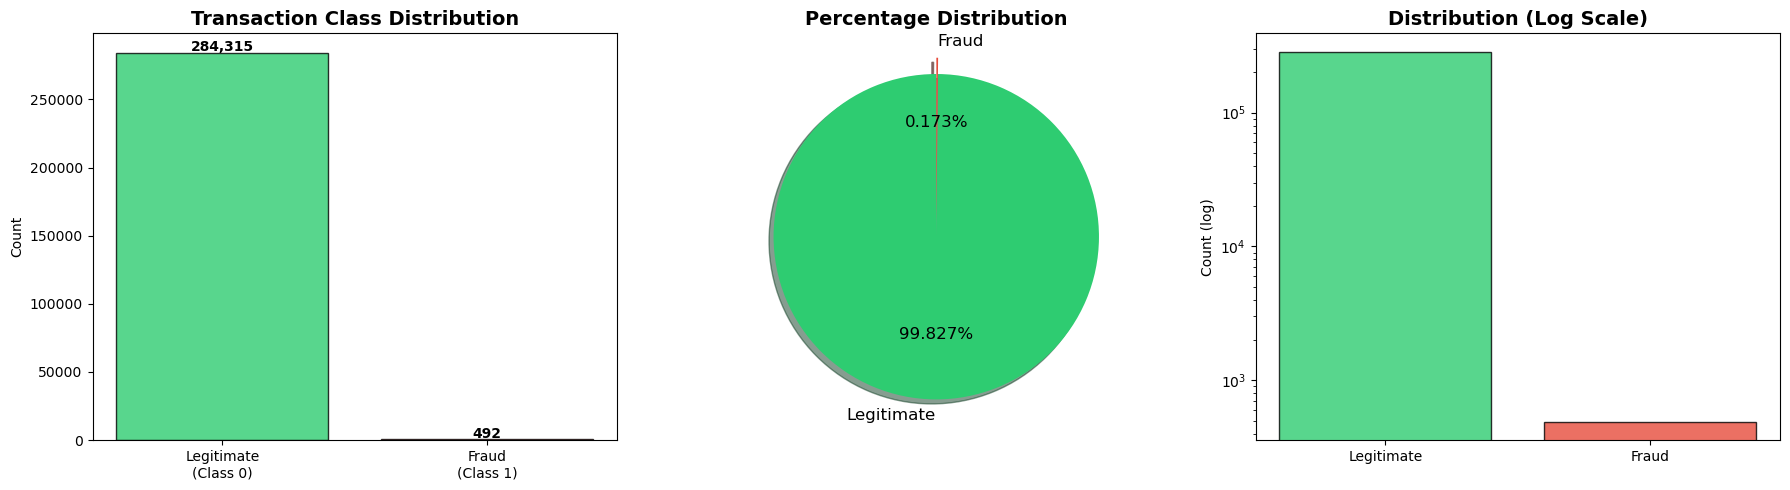

In [7]:
# ============================================================
# LOAD DATA
# ============================================================
# Dataset: https://www.kaggle.com/mlg-ulb/creditcardfraud
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

df = pd.read_csv('creditcard.csv')

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage().sum() / 1e6:.2f} MB")
print(f"\nColumn Types:\n{df.dtypes.value_counts()}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")

# ============================================================
# CLASS DISTRIBUTION
# ============================================================
print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)

class_dist = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

for cls in class_dist.index:
    label = "Legitimate" if cls == 0 else "FRAUD"
    print(f"  Class {cls} ({label}): {class_dist[cls]:>7,} ({class_pct[cls]:.4f}%)")

imbalance_ratio = class_dist[0] / class_dist[1]
print(f"\n  Imbalance Ratio: {imbalance_ratio:.0f}:1")

# ============================================================
# VISUALIZATION - CLASS DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate\n(Class 0)', 'Fraud\n(Class 1)'], 
            class_dist.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_dist.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Pie chart
axes[1].pie(class_dist.values, labels=['Legitimate', 'Fraud'], 
            colors=colors, autopct='%1.3f%%', startangle=90,
            explode=(0, 0.1), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Percentage Distribution', fontsize=14, fontweight='bold')

# Plot 3: Log-scale bar
axes[2].bar(['Legitimate', 'Fraud'], class_dist.values, 
            color=colors, edgecolor='black', alpha=0.8)
axes[2].set_yscale('log')
axes[2].set_title('Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count (log)')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

STATISTICAL SUMMARY BY CLASS

Feature        Legit Mean   Fraud Mean       Diff
--------------------------------------------------
Amount            88.2910     122.2113    33.9203
Time           94838.2023   80746.8069 14091.3953
V1                 0.0083      -4.7719     4.7802
V2                -0.0063       3.6238     3.6300
V3                 0.0122      -7.0333     7.0455
V4                -0.0079       4.5420     4.5499
V14                0.0121      -6.9717     6.9838
V17                0.0115      -6.6658     6.6774


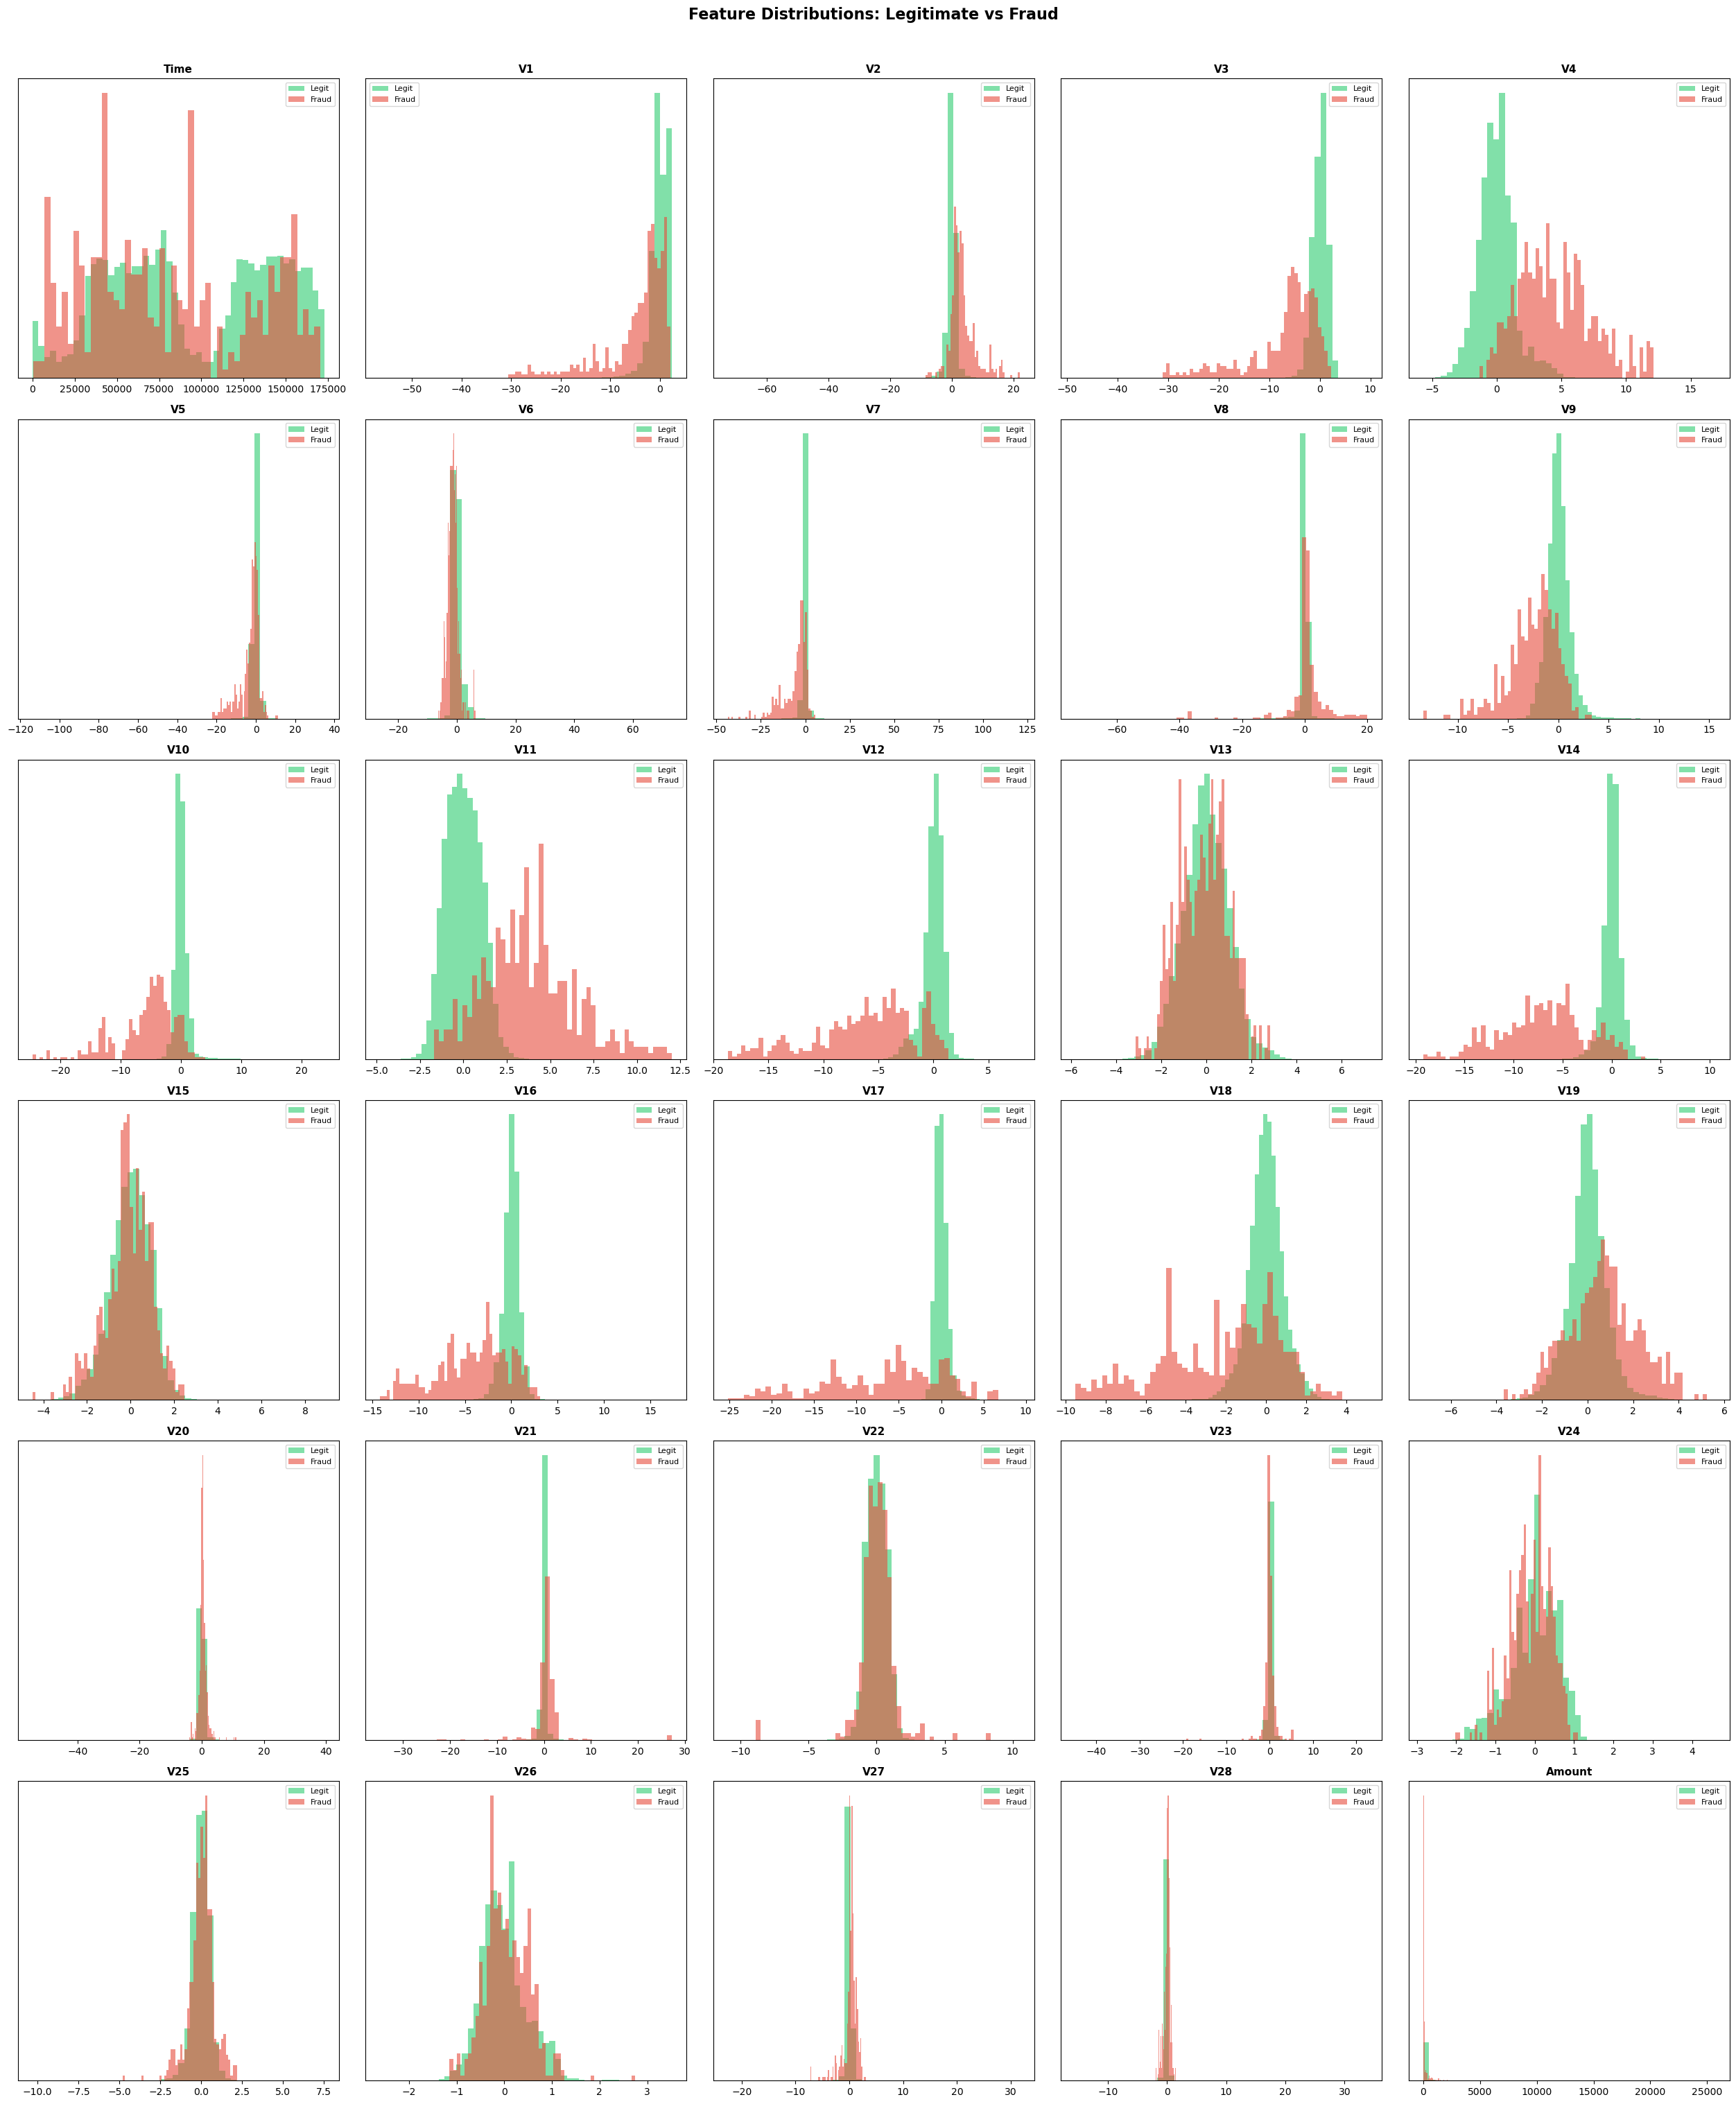

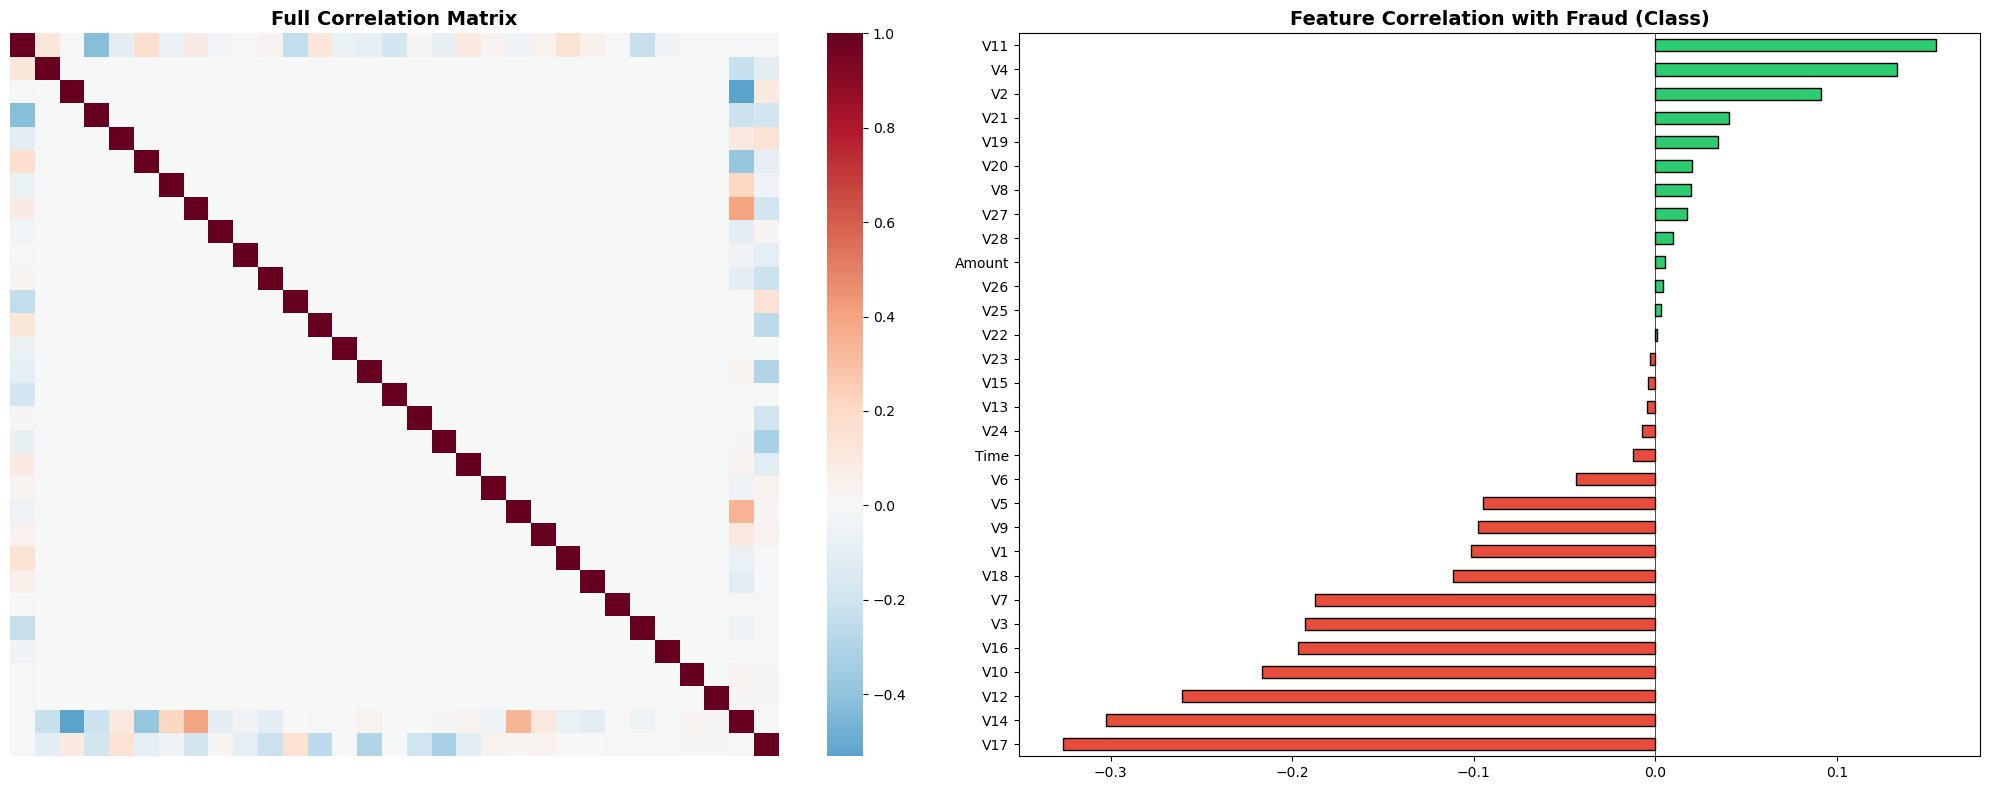


Top features correlated with Fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ============================================================
# STATISTICAL ANALYSIS
# ============================================================
print("="*60)
print("STATISTICAL SUMMARY BY CLASS")
print("="*60)

# Separate by class
legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

print(f"\n{'Feature':<12} {'Legit Mean':>12} {'Fraud Mean':>12} {'Diff':>10}")
print("-" * 50)
for col in ['Amount', 'Time', 'V1', 'V2', 'V3', 'V4', 'V14', 'V17']:
    l_mean = legit[col].mean()
    f_mean = fraud[col].mean()
    diff = abs(f_mean - l_mean)
    print(f"{col:<12} {l_mean:>12.4f} {f_mean:>12.4f} {diff:>10.4f}")

# ============================================================
# FEATURE DISTRIBUTIONS: FRAUD vs LEGITIMATE
# ============================================================
fig, axes = plt.subplots(6, 5, figsize=(25, 30))
axes = axes.flatten()

features = [col for col in df.columns if col != 'Class']

for i, col in enumerate(features):
    ax = axes[i]
    ax.hist(legit[col], bins=50, alpha=0.6, color='#2ecc71', 
            label='Legit', density=True)
    ax.hist(fraud[col], bins=50, alpha=0.6, color='#e74c3c', 
            label='Fraud', density=True)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_yticks([])

# Hide empty subplots
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Legitimate vs Fraud', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full correlation
sns.heatmap(df.corr(), cmap='RdBu_r', center=0, ax=axes[0],
            xticklabels=False, yticklabels=False)
axes[0].set_title('Full Correlation Matrix', fontsize=14, fontweight='bold')

# Correlation with target
target_corr = df.corr()['Class'].drop('Class').sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr.values]
target_corr.plot(kind='barh', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Feature Correlation with Fraud (Class)', 
                   fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlated features
print("\nTop features correlated with Fraud:")
print(target_corr.abs().sort_values(ascending=False).head(10))

In [16]:
# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# DATA PREPROCESSING

print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# Remove duplicates
df_clean = df.drop_duplicates().copy()
print(f"Removed {len(df) - len(df_clean)} duplicates")

# FEATURE ENGINEERING


# Log transform Amount (reduces skewness)
df_clean['Amount_Log'] = np.log1p(df_clean['Amount'])

# Convert time to hour of day
df_clean['Hour'] = (df_clean['Time'] / 3600) % 24

# DEFINE FEATURES AND TARGET

X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

print(f"\nFeature shape: {X.shape}")
print(f"Target shape: {y.shape}")

# TRAIN-TEST SPLIT (STRATIFIED)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test Split:")
print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples:  {X_test.shape[0]}")

print(f"\nTrain distribution:")
print(y_train.value_counts())

print(f"\nTest distribution:")
print(y_test.value_counts())

# FEATURE SCALING

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing Complete!")

DATA PREPROCESSING
Removed 1081 duplicates

Feature shape: (283726, 32)
Target shape: (283726,)

Train/Test Split:
Train samples: 226980
Test samples:  56746

Train distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test distribution:
Class
0    56651
1       95
Name: count, dtype: int64

Preprocessing Complete!


In [18]:
# RESAMPLING TECHNIQUES COMPARISON

print("="*60)
print("RESAMPLING TECHNIQUES")
print("="*60)

resampling_results = {}

# --- 1. SMOTE ---
smote = SMOTE(random_state=42, sampling_strategy=1.0)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
resampling_results['SMOTE'] = {
    'X': X_smote, 'y': y_smote,
    'shape': X_smote.shape,
    'dist': pd.Series(y_smote).value_counts().to_dict()
}

# --- 2. ADASYN ---
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)
resampling_results['ADASYN'] = {
    'X': X_adasyn, 'y': y_adasyn,
    'shape': X_adasyn.shape,
    'dist': pd.Series(y_adasyn).value_counts().to_dict()
}

# --- 3. Borderline-SMOTE ---
bsmote = BorderlineSMOTE(random_state=42)
X_bsmote, y_bsmote = bsmote.fit_resample(X_train, y_train)
resampling_results['Borderline-SMOTE'] = {
    'X': X_bsmote, 'y': y_bsmote,
    'shape': X_bsmote.shape,
    'dist': pd.Series(y_bsmote).value_counts().to_dict()
}

# --- 4. Random Undersampling ---
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
resampling_results['Random Under'] = {
    'X': X_rus, 'y': y_rus,
    'shape': X_rus.shape,
    'dist': pd.Series(y_rus).value_counts().to_dict()
}

# --- 5. NearMiss ---
nm = NearMiss(version=1)
X_nm, y_nm = nm.fit_resample(X_train, y_train)
resampling_results['NearMiss'] = {
    'X': X_nm, 'y': y_nm,
    'shape': X_nm.shape,
    'dist': pd.Series(y_nm).value_counts().to_dict()
}

# --- 6. SMOTE + Tomek Links ---
smt = SMOTETomek(random_state=42)
X_smt, y_smt = smt.fit_resample(X_train, y_train)
resampling_results['SMOTE+Tomek'] = {
    'X': X_smt, 'y': y_smt,
    'shape': X_smt.shape,
    'dist': pd.Series(y_smt).value_counts().to_dict()
}

# --- 7. SMOTE + ENN ---
smenn = SMOTEENN(random_state=42)
X_smenn, y_smenn = smenn.fit_resample(X_train, y_train)
resampling_results['SMOTE+ENN'] = {
    'X': X_smenn, 'y': y_smenn,
    'shape': X_smenn.shape,
    'dist': pd.Series(y_smenn).value_counts().to_dict()
}

# Print comparison
print(f"\n{'Technique':<20} {'Samples':>10} {'Class 0':>10} {'Class 1':>10} {'Ratio':>8}")
print("-" * 62)
print(f"{'Original':<20} {len(y_train):>10,} {(y_train==0).sum():>10,} "
      f"{(y_train==1).sum():>10,} {(y_train==0).sum()/(y_train==1).sum():>8.0f}:1")

for name, res in resampling_results.items():
    c0 = res['dist'].get(0, 0)
    c1 = res['dist'].get(1, 0)
    ratio = c0/c1 if c1 > 0 else float('inf')
    print(f"{name:<20} {c0+c1:>10,} {c0:>10,} {c1:>10,} {ratio:>7.1f}:1")

# VISUALIZE RESAMPLING EFFECTS

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

datasets = [
    ('Original', X_train, y_train),
    ('SMOTE', X_smote, y_smote),
    ('ADASYN', X_adasyn, y_adasyn),
    ('Borderline-SMOTE', X_bsmote, y_bsmote),
    ('Random Under', X_rus, y_rus),
    ('NearMiss', X_nm, y_nm),
    ('SMOTE+Tomek', X_smt, y_smt),
    ('SMOTE+ENN', X_smenn, y_smenn),
]

for i, (name, X_res, y_res) in enumerate(datasets):
    dist = pd.Series(y_res).value_counts()
    bars = axes[i].bar(['Legit (0)', 'Fraud (1)'], 
                        [dist.get(0,0), dist.get(1,0)],
                        color=colors, edgecolor='black', alpha=0.8)
    axes[i].set_title(name, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Count')
    for bar, val in zip(bars, [dist.get(0,0), dist.get(1,0)]):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                     f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Resampling Techniques Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('resampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

RESAMPLING TECHNIQUES


NameError: name 'SMOTE' is not defined

In [ ]:
# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Imbalanced dataset handling
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek, SMOTEENN

# RESAMPLING TECHNIQUES COMPARISON

print("="*60)
print("RESAMPLING TECHNIQUES")
print("="*60)

colors = ['#2ecc71', '#e74c3c']

resampling_results = {}

# -----------------------------
# 1. SMOTE
# -----------------------------
smote = SMOTE(random_state=42, sampling_strategy=1.0)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

resampling_results['SMOTE'] = {
    'X': X_smote,
    'y': y_smote,
    'shape': X_smote.shape,
    'dist': pd.Series(y_smote).value_counts().to_dict()
}

# -----------------------------
# 2. ADASYN
# -----------------------------
adasyn = ADASYN(random_state=42)

X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

resampling_results['ADASYN'] = {
    'X': X_adasyn,
    'y': y_adasyn,
    'shape': X_adasyn.shape,
    'dist': pd.Series(y_adasyn).value_counts().to_dict()
}

# -----------------------------
# 3. Borderline-SMOTE
# -----------------------------
bsmote = BorderlineSMOTE(random_state=42)

X_bsmote, y_bsmote = bsmote.fit_resample(X_train, y_train)

resampling_results['Borderline-SMOTE'] = {
    'X': X_bsmote,
    'y': y_bsmote,
    'shape': X_bsmote.shape,
    'dist': pd.Series(y_bsmote).value_counts().to_dict()
}

# -----------------------------
# 4. Random Undersampling
# -----------------------------
rus = RandomUnderSampler(random_state=42)

X_rus, y_rus = rus.fit_resample(X_train, y_train)

resampling_results['Random Under'] = {
    'X': X_rus,
    'y': y_rus,
    'shape': X_rus.shape,
    'dist': pd.Series(y_rus).value_counts().to_dict()
}

# -----------------------------
# 5. NearMiss
# -----------------------------
nm = NearMiss(version=1)

X_nm, y_nm = nm.fit_resample(X_train, y_train)

resampling_results['NearMiss'] = {
    'X': X_nm,
    'y': y_nm,
    'shape': X_nm.shape,
    'dist': pd.Series(y_nm).value_counts().to_dict()
}

# -----------------------------
# 6. SMOTE + Tomek Links
# -----------------------------
smt = SMOTETomek(random_state=42)

X_smt, y_smt = smt.fit_resample(X_train, y_train)

resampling_results['SMOTE+Tomek'] = {
    'X': X_smt,
    'y': y_smt,
    'shape': X_smt.shape,
    'dist': pd.Series(y_smt).value_counts().to_dict()
}

# -----------------------------
# 7. SMOTE + ENN
# -----------------------------
smenn = SMOTEENN(random_state=42)

X_smenn, y_smenn = smenn.fit_resample(X_train, y_train)

resampling_results['SMOTE+ENN'] = {
    'X': X_smenn,
    'y': y_smenn,
    'shape': X_smenn.shape,
    'dist': pd.Series(y_smenn).value_counts().to_dict()
}

# PRINT COMPARISON TABLE

print(f"\n{'Technique':<20} {'Samples':>10} {'Class 0':>10} {'Class 1':>10} {'Ratio':>8}")
print("-" * 62)

print(f"{'Original':<20} {len(y_train):>10,} {(y_train==0).sum():>10,} "
      f"{(y_train==1).sum():>10,} {(y_train==0).sum()/(y_train==1).sum():>8.0f}:1")

for name, res in resampling_results.items():

    c0 = res['dist'].get(0, 0)
    c1 = res['dist'].get(1, 0)

    ratio = c0/c1 if c1 > 0 else float('inf')

    print(f"{name:<20} {c0+c1:>10,} {c0:>10,} {c1:>10,} {ratio:>7.1f}:1")


# VISUALIZE RESAMPLING EFFECTS

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

datasets = [
    ('Original', X_train, y_train),
    ('SMOTE', X_smote, y_smote),
    ('ADASYN', X_adasyn, y_adasyn),
    ('Borderline-SMOTE', X_bsmote, y_bsmote),
    ('Random Under', X_rus, y_rus),
    ('NearMiss', X_nm, y_nm),
    ('SMOTE+Tomek', X_smt, y_smt),
    ('SMOTE+ENN', X_smenn, y_smenn),
]

for i, (name, X_res, y_res) in enumerate(datasets):

    dist = pd.Series(y_res).value_counts()

    bars = axes[i].bar(
        ['Legit (0)', 'Fraud (1)'],
        [dist.get(0,0), dist.get(1,0)],
        color=colors,
        edgecolor='black',
        alpha=0.8
    )

    axes[i].set_title(name, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Count')

    for bar, val in zip(bars, [dist.get(0,0), dist.get(1,0)]):

        axes[i].text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height(),
            f'{val:,}',
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=9
        )

plt.suptitle('Resampling Techniques Comparison', fontsize=16, fontweight='bold')

plt.tight_layout()

plt.savefig('resampling_comparison.png', dpi=150, bbox_inches='tight')

plt.show()

RESAMPLING TECHNIQUES


In [7]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model"):
    """Comprehensive evaluation for imbalanced classification."""
    
    print(f"\n{'='*55}")
    print(f"  📊 {model_name}")
    print(f"{'='*55}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n  Confusion Matrix:")
    print(f"  ┌─────────────┬──────────────┬──────────────┐")
    print(f"  │             │ Pred Legit   │ Pred Fraud   │")
    print(f"  ├─────────────┼──────────────┼──────────────┤")
    print(f"  │ Act Legit   │ TN={tn:>7,}  │ FP={fp:>7,}  │")
    print(f"  │ Act Fraud   │ FN={fn:>7,}  │ TP={tp:>7,}  │")
    print(f"  └─────────────┴──────────────┴──────────────┘")
    
    # Metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    mcc = matthews_corrcoef(y_true, y_pred)
    
    print(f"\n  Precision (Fraud):  {precision:.4f}  (Of predicted fraud, % correct)")
    print(f"  Recall (Fraud):     {recall:.4f}  (Of actual fraud, % caught)")
    print(f"  F1-Score (Fraud):   {f1:.4f}")
    print(f"  Specificity:        {specificity:.4f}  (Legit correctly identified)")
    print(f"  MCC:                {mcc:.4f}  (Best single metric for imbalanced)")
    
    results = {
        'model': model_name, 'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'precision': precision, 'recall': recall, 'f1': f1,
        'specificity': specificity, 'mcc': mcc
    }
    
    if y_prob is not None:
        auc_roc = roc_auc_score(y_true, y_prob)
        auc_pr = average_precision_score(y_true, y_prob)
        print(f"  AUC-ROC:            {auc_roc:.4f}")
        print(f"  AUC-PR:             {auc_pr:.4f}  (Most important for imbalanced!)")
        results['auc_roc'] = auc_roc
        results['auc_pr'] = auc_pr
    
    return results


def plot_evaluation(y_true, y_pred, y_prob, model_name):
    """Plot confusion matrix, ROC curve, and PR curve."""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Confusion Matrix Heatmap
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[0],
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')
    
    if y_prob is not None:
        # 2. ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
        axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)
        axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curve', fontweight='bold')
        axes[1].legend(fontsize=12)
        axes[1].grid(True, alpha=0.3)
        
        # 3. Precision-Recall Curve
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        axes[2].plot(rec, prec, 'r-', linewidth=2, label=f'AP = {ap:.4f}')
        axes[2].fill_between(rec, prec, alpha=0.1, color='red')
        axes[2].set_xlabel('Recall')
        axes[2].set_ylabel('Precision')
        axes[2].set_title(f'Precision-Recall Curve', fontweight='bold')
        axes[2].legend(fontsize=12)
        axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_evaluation.png', 
                dpi=150, bbox_inches='tight')
    plt.show()

In [11]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model"):
    """Comprehensive evaluation for imbalanced classification."""
    
    print(f"\n{'='*55}")
    print(f"  📊 {model_name}")
    print(f"{'='*55}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n  Confusion Matrix:")
    print(f"  ┌─────────────┬──────────────┬──────────────┐")
    print(f"  │             │ Pred Legit   │ Pred Fraud   │")
    print(f"  ├─────────────┼──────────────┼──────────────┤")
    print(f"  │ Act Legit   │ TN={tn:>7,}  │ FP={fp:>7,}  │")
    print(f"  │ Act Fraud   │ FN={fn:>7,}  │ TP={tp:>7,}  │")
    print(f"  └─────────────┴──────────────┴──────────────┘")
    
    # Metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    mcc = matthews_corrcoef(y_true, y_pred)
    
    print(f"\n  Precision (Fraud):  {precision:.4f}  (Of predicted fraud, % correct)")
    print(f"  Recall (Fraud):     {recall:.4f}  (Of actual fraud, % caught)")
    print(f"  F1-Score (Fraud):   {f1:.4f}")
    print(f"  Specificity:        {specificity:.4f}  (Legit correctly identified)")
    print(f"  MCC:                {mcc:.4f}  (Best single metric for imbalanced)")
    
    results = {
        'model': model_name, 'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'precision': precision, 'recall': recall, 'f1': f1,
        'specificity': specificity, 'mcc': mcc
    }
    
    if y_prob is not None:
        auc_roc = roc_auc_score(y_true, y_prob)
        auc_pr = average_precision_score(y_true, y_prob)
        print(f"  AUC-ROC:            {auc_roc:.4f}")
        print(f"  AUC-PR:             {auc_pr:.4f}  (Most important for imbalanced!)")
        results['auc_roc'] = auc_roc
        results['auc_pr'] = auc_pr
    
    return results


def plot_evaluation(y_true, y_pred, y_prob, model_name):
    """Plot confusion matrix, ROC curve, and PR curve."""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Confusion Matrix Heatmap
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[0],
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')
    
    if y_prob is not None:
        # 2. ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
        axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)
        axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curve', fontweight='bold')
        axes[1].legend(fontsize=12)
        axes[1].grid(True, alpha=0.3)
        
        # 3. Precision-Recall Curve
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        axes[2].plot(rec, prec, 'r-', linewidth=2, label=f'AP = {ap:.4f}')
        axes[2].fill_between(rec, prec, alpha=0.1, color='red')
        axes[2].set_xlabel('Recall')
        axes[2].set_ylabel('Precision')
        axes[2].set_title(f'Precision-Recall Curve', fontweight='bold')
        axes[2].legend(fontsize=12)
        axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_evaluation.png', 
                dpi=150, bbox_inches='tight')
    plt.show()

Credit Card Fraud Detection - TIME HISTOGRAM
Dataset: (284807, 31)

Class distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


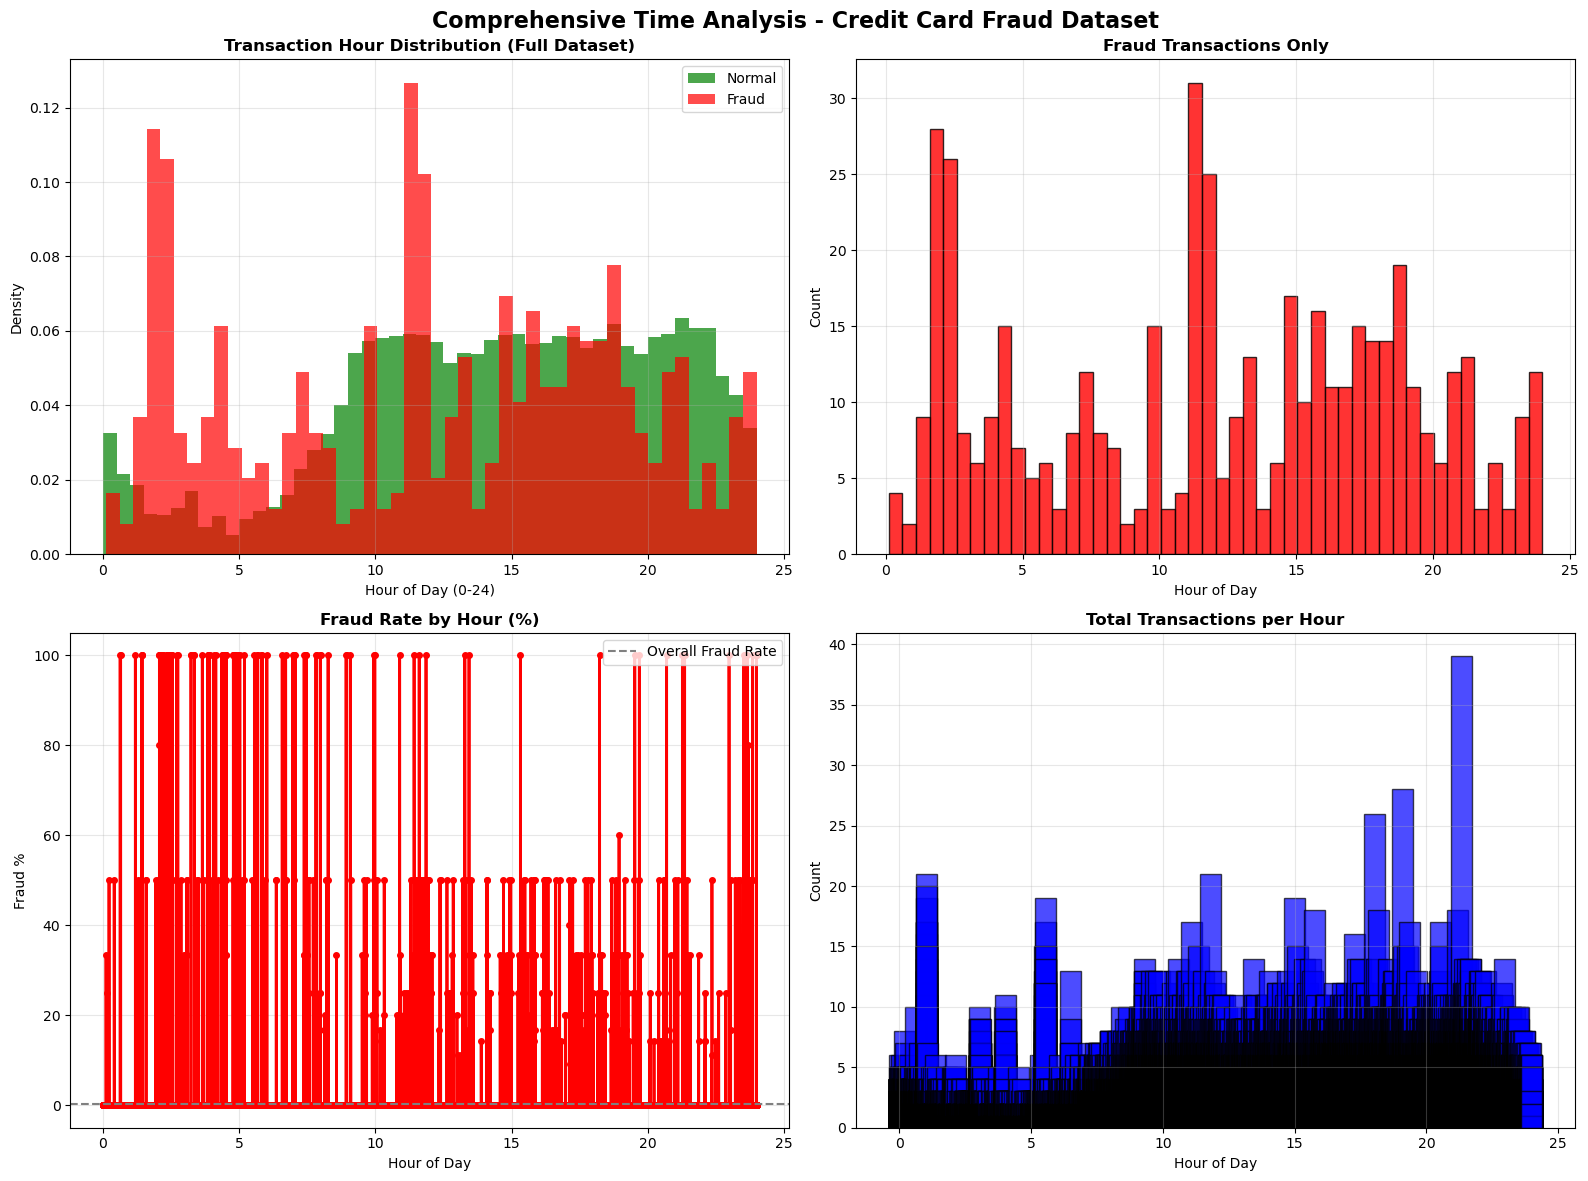


Fraud patterns by time:
Hour with highest fraud rate: 0.6311111111111103
Max fraud rate: 100.000%
Fraud transactions: 492
Time range: 0.0h - 48.0h


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('creditcard.csv')

print("Credit Card Fraud Detection - TIME HISTOGRAM")
print(f"Dataset: {df.shape}")
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# Feature engineering: Convert Time (seconds) to hours (0-48 hours cycle)
df['Hour'] = (df['Time'] / 3600) % 24

# Separate classes
normal = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

# Create comprehensive time histogram
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Full time distribution (hours)
axes[0,0].hist(normal['Hour'], bins=48, alpha=0.7, color='green', label='Normal', density=True)
axes[0,0].hist(fraud['Hour'], bins=48, alpha=0.7, color='red', label='Fraud', density=True)
axes[0,0].set_title('Transaction Hour Distribution (Full Dataset)', fontweight='bold')
axes[0,0].set_xlabel('Hour of Day (0-24)')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Fraud-only (zoomed)
axes[0,1].hist(fraud['Hour'], bins=48, alpha=0.8, color='red', edgecolor='black')
axes[0,1].set_title('Fraud Transactions Only', fontweight='bold')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Count')
axes[0,1].grid(True, alpha=0.3)

# 3. Normal vs Fraud ratio
hourly_fraud_rate = df.groupby('Hour')['Class'].mean()
axes[1,0].plot(hourly_fraud_rate.index, hourly_fraud_rate.values * 100, 'ro-', linewidth=2, markersize=4)
axes[1,0].set_title('Fraud Rate by Hour (%)', fontweight='bold')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Fraud %')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].axhline(y=0.172, color='gray', linestyle='--', label='Overall Fraud Rate')
axes[1,0].legend()

# 4. Count per hour
hourly_counts = df.groupby('Hour').size()
axes[1,1].bar(hourly_counts.index, hourly_counts.values, alpha=0.7, color='blue', edgecolor='black')
axes[1,1].set_title('Total Transactions per Hour', fontweight='bold')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Count')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Comprehensive Time Analysis - Credit Card Fraud Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('time_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
print("\nFraud patterns by time:")
print("Hour with highest fraud rate:", hourly_fraud_rate.idxmax())
print("Max fraud rate:", f"{hourly_fraud_rate.max()*100:.3f}%")
print("Fraud transactions:", len(fraud))
print("Time range:", f"{df['Time'].min()/3600:.1f}h - {df['Time'].max()/3600:.1f}h")


In [13]:
# ============================================================
# MODEL 1: ISOLATION FOREST
# ============================================================
"""
How it works:
┌─────────────────────────────────────────────────┐
│              ISOLATION FOREST                    │
│                                                  │
│  • Randomly selects a feature                   │
│  • Randomly selects a split value               │
│  • Anomalies are ISOLATED faster (fewer splits) │
│  • Normal points need MORE splits               │
│                                                  │
│  Tree depth for anomaly:  ████░░░░░░ (shallow)  │
│  Tree depth for normal:   ████████░░ (deep)     │
│                                                  │
│  contamination = expected % of outliers          │
└─────────────────────────────────────────────────┘
"""

print("\n" + "🌲" * 30)
print("ISOLATION FOREST")
print("🌲" * 30)

# Calculate contamination from training data
contamination_rate = (y_train == 1).sum() / len(y_train)
print(f"Contamination rate: {contamination_rate:.6f}")

iso_forest = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=contamination_rate,
    max_features=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

# Fit on training data
iso_forest.fit(X_train_scaled)

# Predict (-1 for anomaly, 1 for normal)
y_pred_iso = iso_forest.predict(X_test_scaled)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)  # Convert: -1→1 (fraud), 1→0 (legit)

# Anomaly scores (more negative = more anomalous)
y_scores_iso = -iso_forest.decision_function(X_test_scaled)  # Negate for proper scoring

iso_results = evaluate_model(y_test, y_pred_iso, y_scores_iso, "Isolation Forest")
plot_evaluation(y_test, y_pred_iso, y_scores_iso, "Isolation Forest")


# ============================================================
# MODEL 2: LOCAL OUTLIER FACTOR (LOF)
# ============================================================
"""
How it works:
┌─────────────────────────────────────────────────┐
│          LOCAL OUTLIER FACTOR (LOF)              │
│                                                  │
│  • Measures local density of each point         │
│  • Compares density with its neighbors          │
│  • LOF ≈ 1: Normal (similar density to neighb) │
│  • LOF >> 1: Outlier (much lower density)       │
│                                                  │
│  Normal:   ●●●●●  (dense neighborhood)         │
│  Outlier:  ●        ● (sparse, isolated)        │
└─────────────────────────────────────────────────┘
"""

print("\n" + "🎯" * 30)
print("LOCAL OUTLIER FACTOR")
print("🎯" * 30)

lof = LocalOutlierFactor(
    n_neighbors=20,
    algorithm='auto',
    contamination=contamination_rate,
    novelty=True,  # Enable predict on new data
    n_jobs=-1
)

lof.fit(X_train_scaled)

y_pred_lof = lof.predict(X_test_scaled)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)

y_scores_lof = -lof.decision_function(X_test_scaled)

lof_results = evaluate_model(y_test, y_pred_lof, y_scores_lof, "Local Outlier Factor")
plot_evaluation(y_test, y_pred_lof, y_scores_lof, "Local Outlier Factor")


# ============================================================
# MODEL 3: ONE-CLASS SVM
# ============================================================
"""
How it works:
┌─────────────────────────────────────────────────┐
│              ONE-CLASS SVM                       │
│                                                  │
│  • Learns boundary around normal data           │
│  • Maps data to high-dimensional space          │
│  • Finds hyperplane that separates from origin  │
│  • Points outside boundary = anomalies          │
│                                                  │
│     ┌──────────────┐                            │
│     │  ● ● ●  ●   │  ← Normal region           │
│     │    ● ●●  ●  │                            │
│     │  ●  ●● ●    │                            │
│     └──────────────┘                            │
│              ✗  ← Anomaly (outside boundary)    │
└─────────────────────────────────────────────────┘
"""

print("\n" + "🔷" * 30)
print("ONE-CLASS SVM (on subset for speed)")
print("🔷" * 30)

# Use subset for speed (One-Class SVM is slow on large data)
n_subset = 20000
idx = np.random.RandomState(42).choice(len(X_train_scaled), n_subset, replace=False)
X_train_subset = X_train_scaled[idx]

ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=contamination_rate,  # upper bound on fraction of outliers
)

ocsvm.fit(X_train_subset)

y_pred_ocsvm = ocsvm.predict(X_test_scaled)
y_pred_ocsvm = np.where(y_pred_ocsvm == -1, 1, 0)

y_scores_ocsvm = -ocsvm.decision_function(X_test_scaled)

ocsvm_results = evaluate_model(y_test, y_pred_ocsvm, y_scores_ocsvm, "One-Class SVM")
plot_evaluation(y_test, y_pred_ocsvm, y_scores_ocsvm, "One-Class SVM")


# ============================================================
# MODEL 4: ELLIPTIC ENVELOPE
# ============================================================
"""
How it works:
┌─────────────────────────────────────────────────┐
│           ELLIPTIC ENVELOPE                      │
│                                                  │
│  • Assumes data follows Gaussian distribution   │
│  • Fits ellipse (Mahalanobis distance)          │
│  • Robust covariance estimation (MCD)           │
│  • Points outside ellipse = anomalies           │
│                                                  │
│         ╭──────────╮                            │
│        ╱  ● ● ●    ╲                           │
│       │  ● ●●● ●    │  ← Elliptic boundary     │
│        ╲  ● ●  ●   ╱                           │
│         ╰──────────╯   ✗ ← Outlier             │
└─────────────────────────────────────────────────┘
"""

print("\n" + "🟢" * 30)
print("ELLIPTIC ENVELOPE")
print("🟢" * 30)

ee = EllipticEnvelope(
    contamination=contamination_rate,
    random_state=42,
    support_fraction=0.999
)

ee.fit(X_train_scaled[:20000])  # Subset for speed

y_pred_ee = ee.predict(X_test_scaled)
y_pred_ee = np.where(y_pred_ee == -1, 1, 0)

y_scores_ee = -ee.decision_function(X_test_scaled)

ee_results = evaluate_model(y_test, y_pred_ee, y_scores_ee, "Elliptic Envelope")
plot_evaluation(y_test, y_pred_ee, y_scores_ee, "Elliptic Envelope")


🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲
ISOLATION FOREST
🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲


NameError: name 'y_train' is not defined

In [15]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================
import numpy as np
import warnings

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

warnings.filterwarnings("ignore")

# ============================================================
# MODEL 1: ISOLATION FOREST
# ============================================================

print("\n" + "🌲" * 30)
print("ISOLATION FOREST")
print("🌲" * 30)

# Calculate contamination rate
contamination_rate = (y_train == 1).sum() / len(y_train)
print(f"Contamination rate: {contamination_rate:.6f}")

iso_forest = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=contamination_rate,
    max_features=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

# Train
iso_forest.fit(X_train_scaled)

# Predict
y_pred_iso = iso_forest.predict(X_test_scaled)

# Convert (-1 anomaly → fraud)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

# Scores
y_scores_iso = -iso_forest.decision_function(X_test_scaled)

iso_results = evaluate_model(y_test, y_pred_iso, y_scores_iso, "Isolation Forest")
plot_evaluation(y_test, y_pred_iso, y_scores_iso, "Isolation Forest")


# ============================================================
# MODEL 2: LOCAL OUTLIER FACTOR
# ============================================================

print("\n" + "🎯" * 30)
print("LOCAL OUTLIER FACTOR")
print("🎯" * 30)

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=contamination_rate,
    novelty=True,
    n_jobs=-1
)

# Train
lof.fit(X_train_scaled)

# Predict
y_pred_lof = lof.predict(X_test_scaled)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)

# Scores
y_scores_lof = -lof.decision_function(X_test_scaled)

lof_results = evaluate_model(y_test, y_pred_lof, y_scores_lof, "Local Outlier Factor")
plot_evaluation(y_test, y_pred_lof, y_scores_lof, "Local Outlier Factor")


# ============================================================
# MODEL 3: ONE CLASS SVM
# ============================================================

print("\n" + "🔷" * 30)
print("ONE-CLASS SVM")
print("🔷" * 30)

# Subset for speed
n_subset = min(20000, len(X_train_scaled))

rng = np.random.RandomState(42)
idx = rng.choice(len(X_train_scaled), n_subset, replace=False)

X_train_subset = X_train_scaled[idx]

ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=contamination_rate
)

# Train
ocsvm.fit(X_train_subset)

# Predict
y_pred_ocsvm = ocsvm.predict(X_test_scaled)
y_pred_ocsvm = np.where(y_pred_ocsvm == -1, 1, 0)

# Scores
y_scores_ocsvm = -ocsvm.decision_function(X_test_scaled)

ocsvm_results = evaluate_model(y_test, y_pred_ocsvm, y_scores_ocsvm, "One-Class SVM")
plot_evaluation(y_test, y_pred_ocsvm, y_scores_ocsvm, "One-Class SVM")


# ============================================================
# MODEL 4: ELLIPTIC ENVELOPE
# ============================================================

print("\n" + "🟢" * 30)
print("ELLIPTIC ENVELOPE")
print("🟢" * 30)

ee = EllipticEnvelope(
    contamination=contamination_rate,
    random_state=42,
    support_fraction=0.999
)

# Train on subset for speed
ee.fit(X_train_scaled[:20000])

# Predict
y_pred_ee = ee.predict(X_test_scaled)
y_pred_ee = np.where(y_pred_ee == -1, 1, 0)

# Scores
y_scores_ee = -ee.decision_function(X_test_scaled)

ee_results = evaluate_model(y_test, y_pred_ee, y_scores_ee, "Elliptic Envelope")
plot_evaluation(y_test, y_pred_ee, y_scores_ee, "Elliptic Envelope")


🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲
ISOLATION FOREST
🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲


NameError: name 'y_train' is not defined

Dataset Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

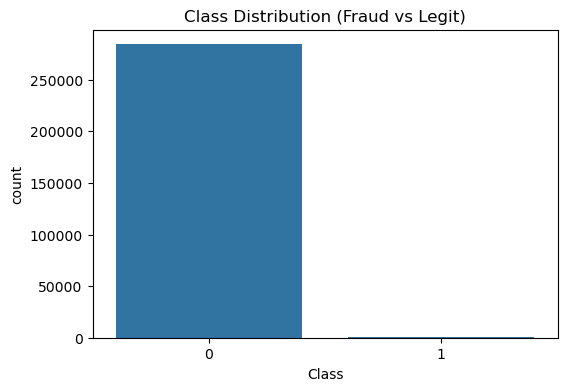

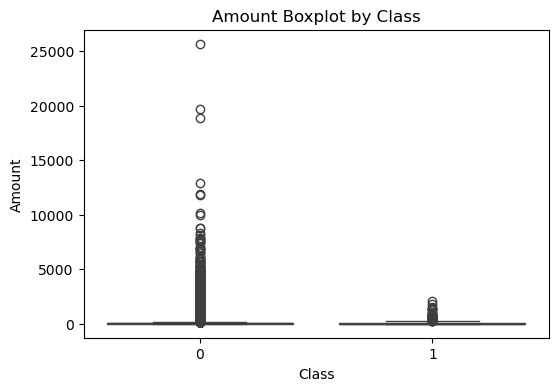

Training samples: (227845, 30)
Testing samples: (56962, 30)
Contamination Rate: 0.001729245759178389

Confusion Matrix:
[[56784    80]
 [   69    29]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.27      0.30      0.28        98

    accuracy                           1.00     56962
   macro avg       0.63      0.65      0.64     56962
weighted avg       1.00      1.00      1.00     56962


Precision: 0.26605504587155965
Recall: 0.29591836734693877
F1 Score: 0.28019323671497587


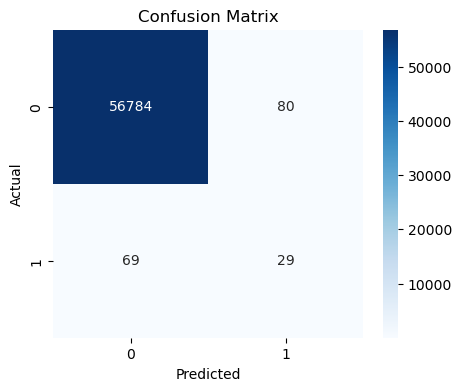

In [16]:
# ==========================================
# CREDIT CARD FRAUD DETECTION PROJECT
# ==========================================

# 1️⃣ IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.ensemble import IsolationForest

# ==========================================
# 2️⃣ LOAD DATASET
# ==========================================

df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3️⃣ CHECK CLASS DISTRIBUTION
# ==========================================

print("\nClass Distribution:")
print(df['Class'].value_counts())

# Plot Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (Fraud vs Legit)")
plt.show()

# ==========================================
# 4️⃣ AMOUNT BOXPLOT (for report)
# ==========================================

plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount Boxplot by Class")
plt.show()

# ==========================================
# 5️⃣ FEATURE SCALING
# ==========================================

scaler = RobustScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df.drop(['Time','Amount'], axis=1, inplace=True)

# ==========================================
# 6️⃣ TRAIN TEST SPLIT
# ==========================================

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

# ==========================================
# 7️⃣ CALCULATE CONTAMINATION RATE
# ==========================================

contamination_rate = (y_train == 1).sum() / len(y_train)

print("Contamination Rate:", contamination_rate)

# ==========================================
# 8️⃣ ISOLATION FOREST MODEL
# ==========================================

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)

# ==========================================
# 9️⃣ PREDICTIONS
# ==========================================

y_pred = iso_forest.predict(X_test)

# IsolationForest outputs
# -1 = anomaly
# 1 = normal

y_pred = np.where(y_pred == -1, 1, 0)

# ==========================================
# 🔟 MODEL EVALUATION
# ==========================================

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ==========================================
# 1️⃣1️⃣ CONFUSION MATRIX GRAPH
# ==========================================

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Dataset Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

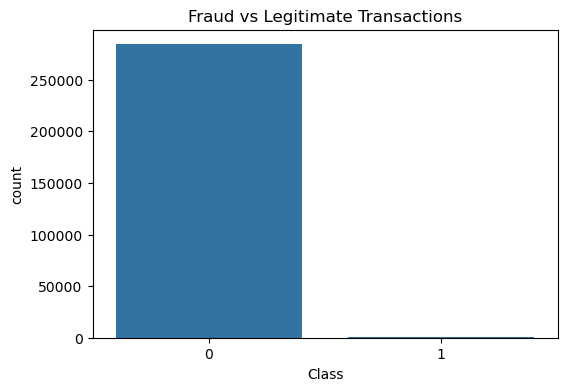

Training Shape: (227845, 30)
Testing Shape: (56962, 30)

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈
LOGISTIC REGRESSION (Balanced)
📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈📈

Model: Logistic Regression

Confusion Matrix:
[[55478  1386]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9720834996210077
PR-AUC: 0.7189705771419241

🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳
RANDOM FOREST
🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳🌳

Model: Random Forest

Confusion Matrix:
[[56860     4]
 [   25    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.74      0.83        98


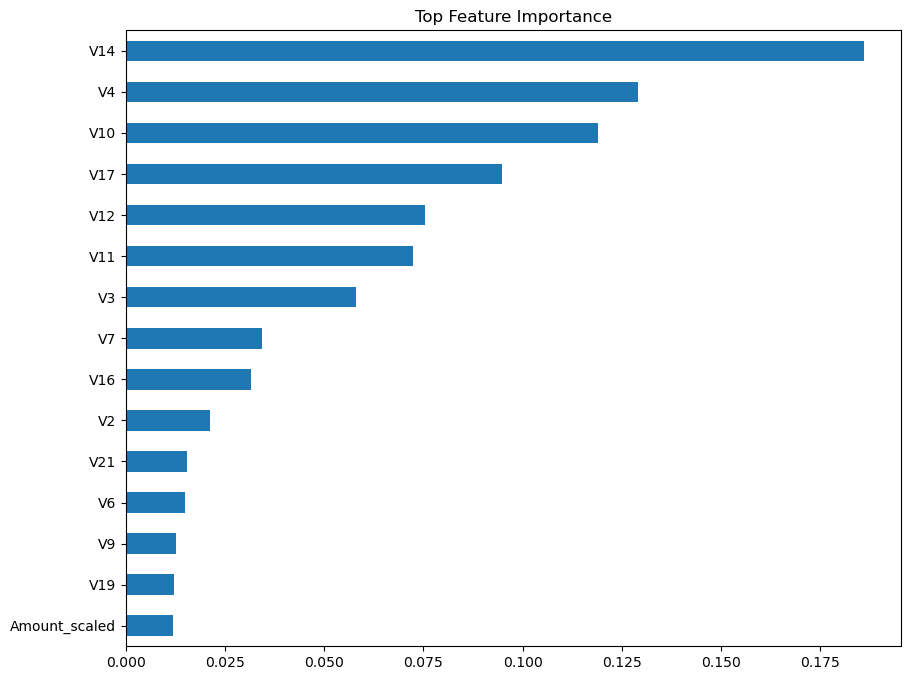


🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
XGBOOST (Weighted)
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

Model: XGBoost Weighted

Confusion Matrix:
[[56854    10]
 [   15    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.85      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9707059737231978
PR-AUC: 0.8875842037794894

⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡
XGBOOST + SMOTE
⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡

Model: XGBoost + SMOTE

Confusion Matrix:
[[56831    33]
 [   12    86]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.88      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.90     56962
weighted avg       1.00     

In [19]:
# ============================================================
# CREDIT CARD FRAUD DETECTION COMPLETE PIPELINE
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb

# =========================
# 2. LOAD DATASET
# =========================

df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# =========================
# 3. CLASS DISTRIBUTION
# =========================

print("\nClass Distribution:")
print(df['Class'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Legitimate Transactions")
plt.show()

# =========================
# 4. FEATURE SCALING
# =========================

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df.drop(['Amount','Time'], axis=1, inplace=True)

# =========================
# 5. TRAIN TEST SPLIT
# =========================

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =========================
# 6. SCALE DATA
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 7. SMOTE BALANCING
# =========================

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_smote).value_counts())

# =========================
# 8. EVALUATION FUNCTION
# =========================

def evaluate_model(y_true, y_pred, y_prob, name):

    print("\n", "="*40)
    print("Model:", name)
    print("="*40)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    roc = roc_auc_score(y_true, y_prob)
    pr = average_precision_score(y_true, y_prob)

    print("ROC-AUC:", roc)
    print("PR-AUC:", pr)

# =========================
# 9. LOGISTIC REGRESSION
# =========================

print("\n"+"📈"*20)
print("LOGISTIC REGRESSION (Balanced)")
print("📈"*20)

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")

# =========================
# 10. RANDOM FOREST
# =========================

print("\n"+"🌳"*20)
print("RANDOM FOREST")
print("🌳"*20)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")

# =========================
# FEATURE IMPORTANCE
# =========================

feat_imp = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10,8))
feat_imp.tail(15).plot(kind='barh')
plt.title("Top Feature Importance")
plt.show()

# =========================
# 11. XGBOOST (WEIGHTED)
# =========================

print("\n"+"🚀"*20)
print("XGBOOST (Weighted)")
print("🚀"*20)

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_xgb, y_prob_xgb, "XGBoost Weighted")

# =========================
# 12. XGBOOST + SMOTE
# =========================

print("\n"+"⚡"*20)
print("XGBOOST + SMOTE")
print("⚡"*20)

xgb_smote = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb_smote.fit(X_smote, y_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_xgb_smote, y_prob_xgb_smote, "XGBoost + SMOTE")

In [ ]:
# ============================================================
# MODEL 5: LOGISTIC REGRESSION (Class Weight Balanced)
# ============================================================

print("\n" + "📈" * 30)
print("LOGISTIC REGRESSION (Balanced)")
print("📈" * 30)

lr_balanced = LogisticRegression(
    class_weight='balanced',  # Auto-adjusts weights inversely proportional
    max_iter=1000,
    random_state=42,
    C=1.0
)
lr_balanced.fit(X_train_scaled, y_train)

y_pred_lr = lr_balanced.predict(X_test_scaled)
y_prob_lr = lr_balanced.predict_proba(X_test_scaled)[:, 1]

lr_results = evaluate_model(y_test, y_pred_lr, y_prob_lr, 
                            "Logistic Regression (Balanced)")
plot_evaluation(y_test, y_pred_lr, y_prob_lr, "Logistic Regression (Balanced)")


# ============================================================
# MODEL 6: RANDOM FOREST (Class Weight + Balanced)
# ============================================================

print("\n" + "🌳" * 30)
print("RANDOM FOREST (Balanced)")  
print("🌳" * 30)

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train, y_train)

y_pred_rf = rf_balanced.predict(X_test.values)
y_prob_rf = rf_balanced.predict_proba(X_test.values)[:, 1]

rf_results = evaluate_model(y_test, y_pred_rf, y_prob_rf, 
                           "Random Forest (Balanced)")
plot_evaluation(y_test, y_pred_rf, y_prob_rf, "Random Forest (Balanced)")

# Feature Importance
feat_imp = pd.Series(rf_balanced.feature_importances_, 
                     index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 10))
feat_imp.tail(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (Random Forest)', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


# ============================================================
# MODEL 7: XGBOOST (with scale_pos_weight)
# ============================================================

print("\n" + "🚀" * 30)
print("XGBOOST (Scale Pos Weight)")
print("🚀" * 30)

# scale_pos_weight = number of negative / number of positive
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='aucpr',  # Use PR-AUC for imbalanced
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_results = evaluate_model(y_test, y_pred_xgb, y_prob_xgb, 
                             "XGBoost (Weighted)")
plot_evaluation(y_test, y_pred_xgb, y_prob_xgb, "XGBoost (Weighted)")


# ============================================================
# MODEL 8: XGBOOST + SMOTE
# ============================================================

print("\n" + "⚡" * 30)
print("XGBOOST + SMOTE")
print("⚡" * 30)

xgb_smote = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='aucpr',
    n_jobs=-1
)

# Train on SMOTE data
xgb_smote.fit(X_smote, y_smote, verbose=False)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

xgb_smote_results = evaluate_model(y_test, y_pred_xgb_smote, y_prob_xgb_smote,
                                   "XGBoost + SMOTE")
plot_evaluation(y_test, y_pred_xgb_smote, y_prob_xgb_smote, "XGBoost + SMOTE")

Dataset Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

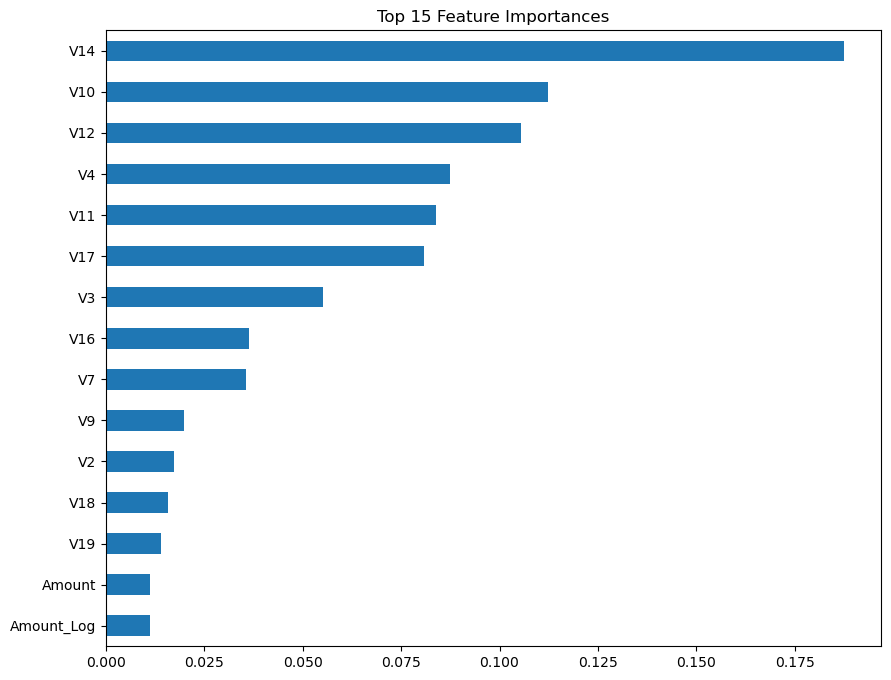


🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
XGBOOST
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

XGBoost Weighted
Precision: 0.8723404255319149
Recall: 0.8367346938775511
F1 Score: 0.8541666666666666
ROC-AUC: 0.9825945255704984
PR-AUC: 0.8838928370460574

Confusion Matrix
[[56852    12]
 [   16    82]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962


⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡
XGBOOST + SMOTE
⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡

XGBoost + SMOTE
Precision: 0.7706422018348624
Recall: 0.8571428571428571
F1 Score: 0.8115942028985508
ROC-AUC: 0.9821265274539754
PR-AUC: 0.8835649254539625

Confusion Matrix
[[56839    25]
 [   14    84]]

Classification Report
              precision    recall  f1-score   support

       

In [2]:

# Install packages if needed
# pip install pandas numpy scikit-learn imbalanced-learn xgboost seaborn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
import xgboost as xgb


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# ============================================================
# FEATURE ENGINEERING
# ============================================================

df['Amount_Log'] = np.log1p(df['Amount'])
df['Hour'] = (df['Time'] // 3600) % 24


# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop("Class", axis=1)
y = df["Class"]


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


# ============================================================
# SCALING
# ============================================================

robust = RobustScaler()

X_train[['Amount','Time']] = robust.fit_transform(X_train[['Amount','Time']])
X_test[['Amount','Time']] = robust.transform(X_test[['Amount','Time']])


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# SMOTE
# ============================================================

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_smote))


# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(y_true, y_pred, y_prob, name):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    roc = roc_auc_score(y_true, y_prob)
    pr = average_precision_score(y_true, y_prob)

    print("\n===============================")
    print(name)
    print("===============================")

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)
    print("PR-AUC:", pr)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))


# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================

print("\n" + "📈"*30)
print("LOGISTIC REGRESSION")
print("📈"*30)

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")


# ============================================================
# MODEL 2: RANDOM FOREST
# ============================================================

print("\n" + "🌳"*30)
print("RANDOM FOREST")
print("🌳"*30)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")


# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feat_imp = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10,8))
feat_imp.tail(15).plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.show()


# ============================================================
# MODEL 3: XGBOOST (Weighted)
# ============================================================

print("\n" + "🚀"*30)
print("XGBOOST")
print("🚀"*30)

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_xgb, y_prob_xgb, "XGBoost Weighted")


# ============================================================
# MODEL 4: XGBOOST + SMOTE
# ============================================================

print("\n" + "⚡"*30)
print("XGBOOST + SMOTE")
print("⚡"*30)

xgb_smote = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr'
)

xgb_smote.fit(X_smote, y_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_xgb_smote, y_prob_xgb_smote, "XGBoost + SMOTE")

In [ ]:
# ===============================
# SPAM MAIL DETECTION PROJECT
# ===============================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import os


# ===============================
# 2. LOAD DATASET
# ===============================

# Change path if your dataset is somewhere else
file_path = "spam.csv"

# Check if file exists
if os.path.exists(file_path):
    df = pd.read_csv(file_path, encoding="latin-1")
else:
    print("Dataset not found. Please put spam.csv in this folder.")
    exit()

# Keep only required columns
df = df[['v1','v2']]

# Rename columns
df.columns = ['label','message']

print("Dataset Loaded Successfully\n")
print(df.head())


# ===============================
# 3. DATASET INFO
# ===============================

print("\nDataset Shape:", df.shape)

print("\nClass Distribution:")
print(df['label'].value_counts())


# ===============================
# 4. LABEL ENCODING
# ===============================

df['label'] = df['label'].map({'ham':0,'spam':1})


# ===============================
# 5. TRAIN TEST SPLIT
# ===============================

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===============================
# 6. TEXT VECTORIZATION
# ===============================

vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


# ===============================
# 7. NAIVE BAYES MODEL
# ===============================

nb_model = MultinomialNB()

nb_model.fit(X_train_vec, y_train)

y_pred_nb = nb_model.predict(X_test_vec)

print("\nNaive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))


# ===============================
# 8. LOGISTIC REGRESSION MODEL
# ===============================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_vec, y_train)

y_pred_lr = lr_model.predict(X_test_vec)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))


# ===============================
# 9. CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ===============================
# 10. TEST CUSTOM MESSAGE
# ===============================

msg = ["Congratulations! You have won a free lottery ticket"]

msg_vec = vectorizer.transform(msg)

prediction = lr_model.predict(msg_vec)

if prediction[0] == 1:
    print("\nPrediction: SPAM")
else:
    print("\nPrediction: HAM (Not Spam)")

Dataset not found. Please put spam.csv in this folder.


KeyError: "None of [Index(['v1', 'v2'], dtype='object')] are in the [columns]"

: 